# Texas Electric Power Transmission Lines

Loads US transmission line data (shapefile/GeoJSON), filters to Texas, and plots the network.

In [151]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths to your data (use GeoJSON for single-file simplicity)
GEOJSON_PATH = r"C:\Users\pmeijer\Downloads\Electric_Power_Transmission_Lines_shp.geojson"
SHP_PATH = r"C:\Users\pmeijer\Downloads\US_Electric_Power_Transmission_Lines_-5565712113468837121 (1)\Electric_Power_Transmission_Lines_A.shp"

if Path(GEOJSON_PATH).exists():
    lines = gpd.read_file(GEOJSON_PATH)
    print("Loaded from GeoJSON")
elif Path(SHP_PATH).exists():
    lines = gpd.read_file(SHP_PATH)
    print("Loaded from shapefile")
else:
    raise FileNotFoundError("Neither GeoJSON nor shapefile found. Update paths above.")

print(f"CRS: {lines.crs}")
print(f"Total lines: {len(lines)}")
print(f"Columns: {lines.columns.tolist()}")
lines.head()

Loaded from GeoJSON
CRS: EPSG:4326
Total lines: 89744
Columns: ['FID', 'OBJECTID', 'ID', 'TYPE', 'STATUS', 'NAICS_CODE', 'NAICS_DESC', 'SOURCE', 'SOURCEDATE', 'VAL_METHOD', 'VAL_DATE', 'OWNER', 'VOLTAGE', 'VOLT_CLASS', 'INFERRED', 'SUB_1', 'SUB_2', 'SHAPE_Leng', 'geometry']


,FID,OBJECTID,ID,TYPE,STATUS,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,OWNER,VOLTAGE,VOLT_CLASS,INFERRED,SUB_1,SUB_2,SHAPE_Leng,geometry
0,1,501,200435,AC; OVERHEAD,NOT AVAILABLE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,IMAGERY,"Thu, 12 Jun 2014 00:00:00 GMT",IMAGERY,"Thu, 12 Jun 2014 00:00:00 GMT",PUD NO 1 OF CLARK COUNTY - (WA),115.0,100-161,Y,TAP203196,LINDON,5257.818660,"LINESTRING (-122.56297 45.69328, -122.55869 45..."
1,2,502,200436,AC; OVERHEAD,NOT AVAILABLE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,IMAGERY,"Thu, 12 Jun 2014 00:00:00 GMT",IMAGERY,"Thu, 12 Jun 2014 00:00:00 GMT",PUD NO 1 OF CLARK COUNTY - (WA),115.0,100-161,Y,TAP203232,MANOR,6888.216636,"LINESTRING (-122.59917 45.69343, -122.59916 45..."
2,3,503,200437,AC; OVERHEAD,NOT AVAILABLE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,IMAGERY,"Thu, 12 Jun 2014 00:00:00 GMT",IMAGERY,"Thu, 12 Jun 2014 00:00:00 GMT",PUD NO 1 OF CLARK COUNTY - (WA),115.0,100-161,Y,TAP203192,TAP203199,4364.102519,"LINESTRING (-122.53183 45.65026, -122.53194 45..."
3,4,504,200438,AC; OVERHEAD,NOT AVAILABLE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,IMAGERY,"Thu, 12 Jun 2014 00:00:00 GMT",IMAGERY,"Thu, 12 Jun 2014 00:00:00 GMT",PUD NO 1 OF CLARK COUNTY - (WA),115.0,100-161,Y,TAP203194,TAP203199,3058.601480,"LINESTRING (-122.50572 45.67927, -122.50843 45..."
4,5,505,200439,AC; OVERHEAD,NOT AVAILABLE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,IMAGERY,"Thu, 12 Jun 2014 00:00:00 GMT",IMAGERY,"Thu, 12 Jun 2014 00:00:00 GMT",PUD NO 1 OF CLARK COUNTY - (WA),115.0,100-161,Y,BURTON,TAP203200,1680.404127,"LINESTRING (-122.55867 45.643, -122.55877 45.6..."


In [152]:
# Get Texas boundary (Natural Earth 10m states)
states_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip"
states = gpd.read_file(states_url)
# Natural Earth: filter by state name or postal code
texas = states[(states.name == "Texas") | (states.postal == "TX")].copy()
texas = texas.to_crs(lines.crs)
print(f"Texas boundary: {texas.crs}")

Texas boundary: EPSG:4326


In [153]:
# Clip transmission lines to Texas
lines_texas = gpd.clip(lines, texas)
print(f"Transmission lines in Texas: {len(lines_texas)}")

Transmission lines in Texas: 6641


In [154]:
# Load Texas county boundaries (Natural Earth 10m admin 2); clip to Texas so we don't rely on state column names
counties_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_2_counties.zip"
counties_all = gpd.read_file(counties_url).to_crs(lines.crs)
counties = gpd.clip(counties_all, texas)
print(f"Texas counties: {len(counties)}")

Texas counties: 287


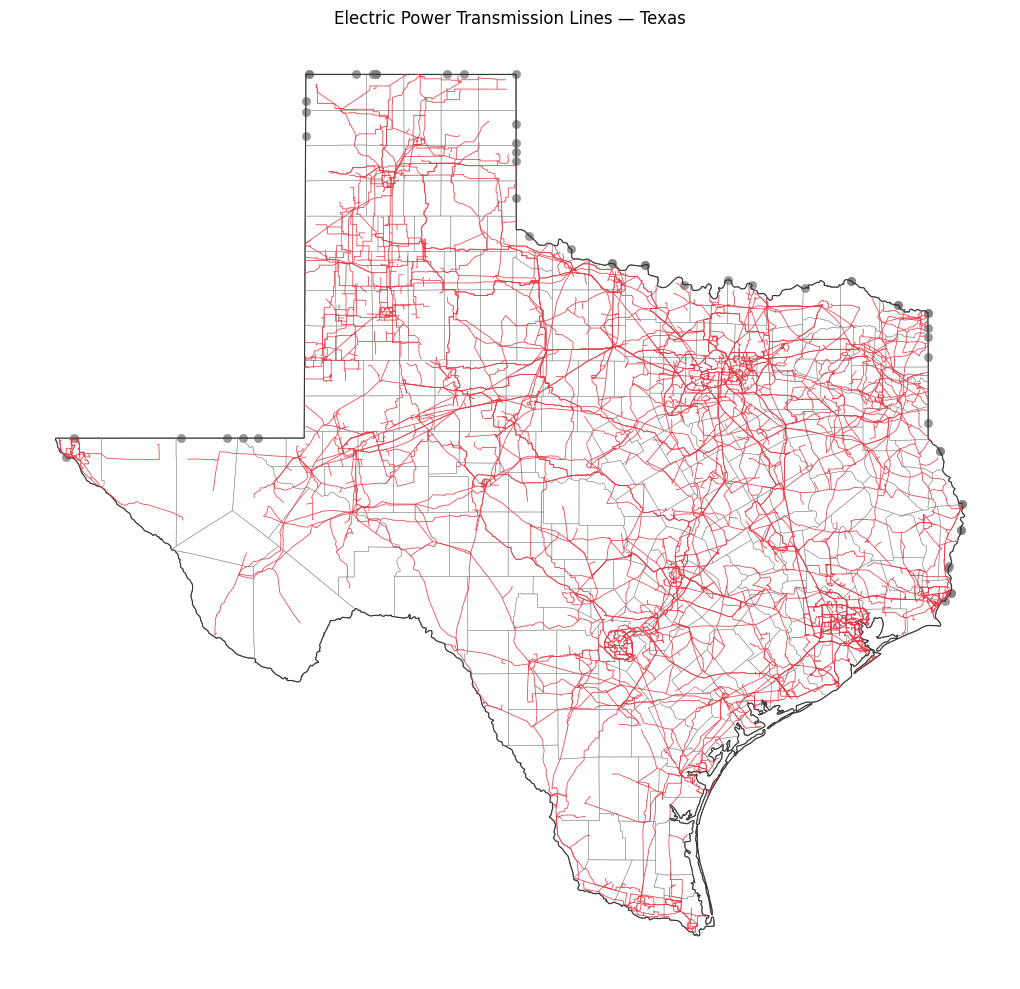

In [155]:
# Plot Texas transmission network (state outline + county lines + transmission lines)
fig, ax = plt.subplots(figsize=(12, 10))
texas.boundary.plot(ax=ax, color="black", linewidth=0.8)
counties.boundary.plot(ax=ax, color="gray", linewidth=0.35, alpha=0.8)
lines_texas.plot(ax=ax, color="#e63946", linewidth=0.6, alpha=0.9)
ax.set_title("Electric Power Transmission Lines — Texas")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [156]:
# Optional: plot with basemap (requires contextily)
try:
    import contextily as ctx
    fig, ax = plt.subplots(figsize=(12, 10))
    counties.boundary.plot(ax=ax, color="gray", linewidth=0.4, alpha=0.7)
    lines_texas.plot(ax=ax, color="#e63946", linewidth=0.7, alpha=0.85)
    ctx.add_basemap(ax, crs=lines_texas.crs, source=ctx.providers.CartoDB.Positron, zorder=0)
    ax.set_title("Electric Power Transmission Lines — Texas")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Basemap skipped: {e}")

Basemap skipped: No module named 'contextily'


## Transmission Readiness Metrics

For each Texas county we compute:
1. **Capacity density** — total transmission capacity (GW-miles) per sq mile
2. **High-voltage line count** — number of unique lines ≥345 kV
3. **Distance to major metro** — geodesic miles to nearest of Harris, Dallas, Tarrant, Bexar, Travis (0 if county is one of them)

Then we convert to percentile rankings, combine into a composite score, and classify readiness levels.

In [157]:
import pandas as pd
import numpy as np
from pyproj import Geod
# Use a Texas projected CRS for length/area in sensible units (meters)
TEXAS_CRS = "EPSG:3083"  # Texas Centric Albers Equal Area (meters)
geod = Geod(ellps="WGS84")

# Project for calculations
counties_prj = counties.to_crs(TEXAS_CRS)
lines_prj = lines_texas.to_crs(TEXAS_CRS)

# Ensure VOLTAGE is numeric
lines_prj["VOLTAGE"] = pd.to_numeric(lines_prj["VOLTAGE"], errors="coerce")
lines_prj = lines_prj[lines_prj["VOLTAGE"].notna()].copy()

# County area in sq miles (area in m², 1 mi² = 2.58999e6 m²)
counties_prj["area_sq_miles"] = counties_prj.geometry.area / 2.58999e6

# --- METRIC 1: CAPACITY DENSITY ---
# For each county, intersect lines and sum voltage_kV * length_miles / 1000, then / area
results = []
for idx, row in counties_prj.iterrows():
    county_geom = row.geometry
    total_gw_miles = 0.0
    for _, line in lines_prj.iterrows():
        inter = line.geometry.intersection(county_geom)
        if inter.is_empty or inter.geom_type == "Point":
            continue
        length_m = inter.length
        length_miles = length_m / 1609.34
        v = float(line["VOLTAGE"])
        total_gw_miles += v * length_miles / 1000.0
    area_sq_mi = row["area_sq_miles"]
    capacity_density = total_gw_miles / area_sq_mi if area_sq_mi > 0 else 0.0
    results.append({"idx": idx, "capacity_density": capacity_density, "total_gw_miles": total_gw_miles})

cap_df = pd.DataFrame(results).set_index("idx")
counties_prj["capacity_density"] = cap_df.reindex(counties_prj.index)["capacity_density"].fillna(0)
counties_prj["total_gw_miles"] = cap_df.reindex(counties_prj.index)["total_gw_miles"].fillna(0)

# --- METRIC 2: HIGH-VOLTAGE LINE COUNT (>= 345 kV) ---
hv = lines_prj[lines_prj["VOLTAGE"] >= 345].copy()
hv_count = []
for idx, row in counties_prj.iterrows():
    n = 0
    seen_ids = set()
    for _, line in hv.iterrows():
        if line.geometry.intersects(row.geometry):
            lid = line.get("ID", line.get("OBJECTID", id(line.geometry)))
            if lid not in seen_ids:
                seen_ids.add(lid)
                n += 1
    hv_count.append(n)
counties_prj["hv_line_count"] = hv_count

# --- METRIC 3: DISTANCE TO MAJOR METRO (miles) ---
# Major metros: Harris, Dallas, Tarrant, Bexar, Travis
MAJOR_METROS = ["Harris", "Dallas", "Tarrant", "Bexar", "Travis"]
name_col = next((c for c in ["NAME_2", "name", "NAME_1", "admin2"] if c in counties_prj.columns), None)
county_names = counties_prj[name_col].astype(str).str.strip() if name_col else pd.Series("", index=counties_prj.index)
# Match metro: "Harris", "Harris County", "HARRIS", etc.
metro_mask = county_names.str.upper().str.replace(" COUNTY", "").str.strip().isin([m.upper() for m in MAJOR_METROS])
# Centroids in WGS84 for geodesic (use projected centroid then transform to get valid lon/lat)
counties_wgs84 = counties.to_crs("EPSG:4326")
centroids_proj = counties_prj.geometry.centroid
centroids_wgs84 = gpd.GeoSeries(centroids_proj, crs=TEXAS_CRS).to_crs("EPSG:4326")
counties_wgs84["_centroid"] = centroids_wgs84.values
metro_centroids = counties_wgs84.loc[metro_mask, "_centroid"]
metro_pts = list(metro_centroids.values)

def geodesic_miles(lon1, lat1, lon2, lat2):
    try:
        return geod.inv(lon1, lat1, lon2, lat2)[2] / 1609.34
    except Exception:
        return np.nan

dist_to_metro = []
for idx, row in counties_wgs84.iterrows():
    if idx in metro_mask.index and metro_mask.at[idx]:
        dist_to_metro.append(0.0)
        continue
    c = row["_centroid"]
    lon1, lat1 = c.x, c.y
    if np.isnan(lon1) or np.isnan(lat1):
        dist_to_metro.append(500.0)
        continue
    d_min = np.inf
    for mp in metro_pts:
        lon2, lat2 = mp.x, mp.y
        d = geodesic_miles(lon1, lat1, lon2, lat2)
        if not np.isnan(d) and d < d_min:
            d_min = d
    dist_to_metro.append(d_min if d_min != np.inf else 500.0)
counties_prj["distance_to_metro"] = dist_to_metro
# If any NaN remain (e.g. from bad geometry), fill with max or 500
dmax = counties_prj["distance_to_metro"].max()
counties_prj["distance_to_metro"] = counties_prj["distance_to_metro"].fillna(500.0 if np.isnan(dmax) else dmax)

# Attach back to original counties (same index)
counties["capacity_density"] = counties_prj["capacity_density"].values
counties["hv_line_count"] = counties_prj["hv_line_count"].values
counties["distance_to_metro"] = counties_prj["distance_to_metro"].values
counties["area_sq_miles"] = counties_prj["area_sq_miles"].values
print("Metrics computed. Sample:")
print(counties[["capacity_density", "hv_line_count", "distance_to_metro"]].head(10))

Metrics computed. Sample:
      capacity_density  hv_line_count  distance_to_metro
89            0.001898              0              500.0
86           -0.241549              0              500.0
88            0.000405              0              500.0
2984         -3.146897              2              500.0
2931         -5.155664              3              500.0
87            0.001256              0              500.0
85            0.002745              0              500.0
503          -0.889955              0              500.0
2983        -46.614749              2              500.0
2982        -78.938177              1              500.0


In [158]:
# Percentile rankings (0-1); higher is better for capacity and HV, so for distance we use inverse
# Use fillna so NaN inputs don't produce NaN ranks
counties["capacity_pct"] = counties["capacity_density"].fillna(0).rank(pct=True)
counties["hv_pct"] = counties["hv_line_count"].fillna(0).rank(pct=True)
counties["proximity_pct"] = (1 / (counties["distance_to_metro"].fillna(999) + 1)).rank(pct=True)

# Composite readiness score (weighted average)
counties["readiness_score"] = (
    0.50 * counties["capacity_pct"]
    + 0.30 * counties["hv_pct"]
    + 0.20 * counties["proximity_pct"]
)

def classify_readiness(score):
    if score >= 0.8:
        return "Transmission-Ready"
    elif score >= 0.6:
        return "Well-Positioned"
    elif score >= 0.4:
        return "Requires Assessment"
    elif score >= 0.2:
        return "Significant Constraints"
    else:
        return "Not Viable"

counties["readiness_level"] = counties["readiness_score"].apply(classify_readiness)
print(counties["readiness_level"].value_counts().sort_index())

readiness_level
Not Viable                   5
Requires Assessment        128
Significant Constraints     76
Transmission-Ready          18
Well-Positioned             60
Name: count, dtype: int64


In [159]:
# Load data centers from the DOE Texas Excel file (exact path)
DC_PATH = r"C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\data_centres_doe_texas.xlsx"
xl = pd.ExcelFile(DC_PATH)
# Use first sheet that has data and looks like a data table (has several columns)
for sheet in xl.sheet_names:
    dc_df = pd.read_excel(DC_PATH, sheet_name=sheet)
    if dc_df.shape[0] > 0 and dc_df.shape[1] >= 2:
        break
dc_cols_lower = {str(c).strip(): str(c).strip().lower() for c in dc_df.columns}
col_county = next((k for k, v in dc_cols_lower.items() if "county" in v), list(dc_df.columns)[0])
col_mw = next((k for k, v in dc_cols_lower.items() if "mw" in v or "capacity" in v or ("total" in v and "power" in v)), None)
if col_mw is None:
    col_mw = next((k for k, v in dc_cols_lower.items() if "total" in v or "power" in v), list(dc_df.columns)[-1])
col_lat = next((k for k, v in dc_cols_lower.items() if "lat" in v or v == "y" or "latitude" in v), None)
col_lon = next((k for k, v in dc_cols_lower.items() if "lon" in v or "long" in v or v == "x" or "longitude" in v), None)
dc_df = dc_df.rename(columns={col_county: "County", col_mw: "Total_MW"})
if col_lat and col_lon and col_lat in dc_df.columns and col_lon in dc_df.columns:
    dc_df["lat"] = pd.to_numeric(dc_df[col_lat], errors="coerce")
    dc_df["lon"] = pd.to_numeric(dc_df[col_lon], errors="coerce")
else:
    dc_df["lat"] = np.nan
    dc_df["lon"] = np.nan
dc_df["Total_MW"] = pd.to_numeric(dc_df["Total_MW"], errors="coerce").fillna(0)
# If "County" column looks like coordinates (e.g. "32.305036, -102.637815"), parse as lat, lon
def parse_lat_lon(s):
    if pd.isna(s):
        return np.nan, np.nan
    s = str(s).strip().replace("\xa0", " ")
    parts = [p.strip() for p in s.split(",")]
    if len(parts) == 2:
        try:
            a, b = float(parts[0]), float(parts[1])
            # Texas: lat 25-37, lon -107 to -93
            if 25 <= a <= 40 and -110 <= b <= -90:
                return a, b
            if 25 <= b <= 40 and -110 <= a <= -90:
                return b, a
            if -100 <= a <= 100 and -100 <= b <= 100:
                return a, b
        except ValueError:
            pass
    return np.nan, np.nan

first_val = dc_df["County"].iloc[0] if len(dc_df) > 0 else ""
if first_val and "," in str(first_val) and any(c.isdigit() for c in str(first_val)):
    lat_lon = dc_df["County"].apply(lambda s: parse_lat_lon(s))
    dc_df["lat"] = [x[0] for x in lat_lon]
    dc_df["lon"] = [x[1] for x in lat_lon]
dc_df = dc_df[dc_df["Total_MW"].notna() | dc_df["lat"].notna()]
print(f"Loaded from: {DC_PATH}")
print(f"Sheet: {sheet} | Data centers: {len(dc_df)}")
print(f"Columns: County (or coords), Total_MW, lat, lon")
print(dc_df[["County", "Total_MW", "lat", "lon"]].head(10))

Loaded from: C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\data_centres_doe_texas.xlsx
Sheet: Data_Centres | Data centers: 65
Columns: County (or coords), Total_MW, lat, lon
                   County  Total_MW        lat         lon
0  32.305036, -102.637815     205.0  32.305036 -102.637815
1   33.616490, -99.213515     166.0  33.616490  -99.213515
2   31.037345, -97.478744     657.0  31.037345  -97.478744
3   29.448958, -98.520026    1453.6  29.448958  -98.520026
4   31.900417, -97.634343      40.0  31.900417  -97.634343
5   33.445757, -94.423332       2.0  33.445757  -94.423332
6   30.660799, -96.302385       6.0  30.660799  -96.302385
7  34.530264, -101.208593     100.0  34.530264 -101.208593
8   32.580697, -93.882405       0.9  32.580697  -93.882405
9   29.836844, -97.619919     144.0  29.836844  -97.619919


Data centers to plot: 62 (from 65 rows in sheet, all within Texas)


C:\Users\pmeijer\AppData\Local\Temp\ipykernel_10208\3765422329.py:91: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  texas_geom = texas.geometry.unary_union


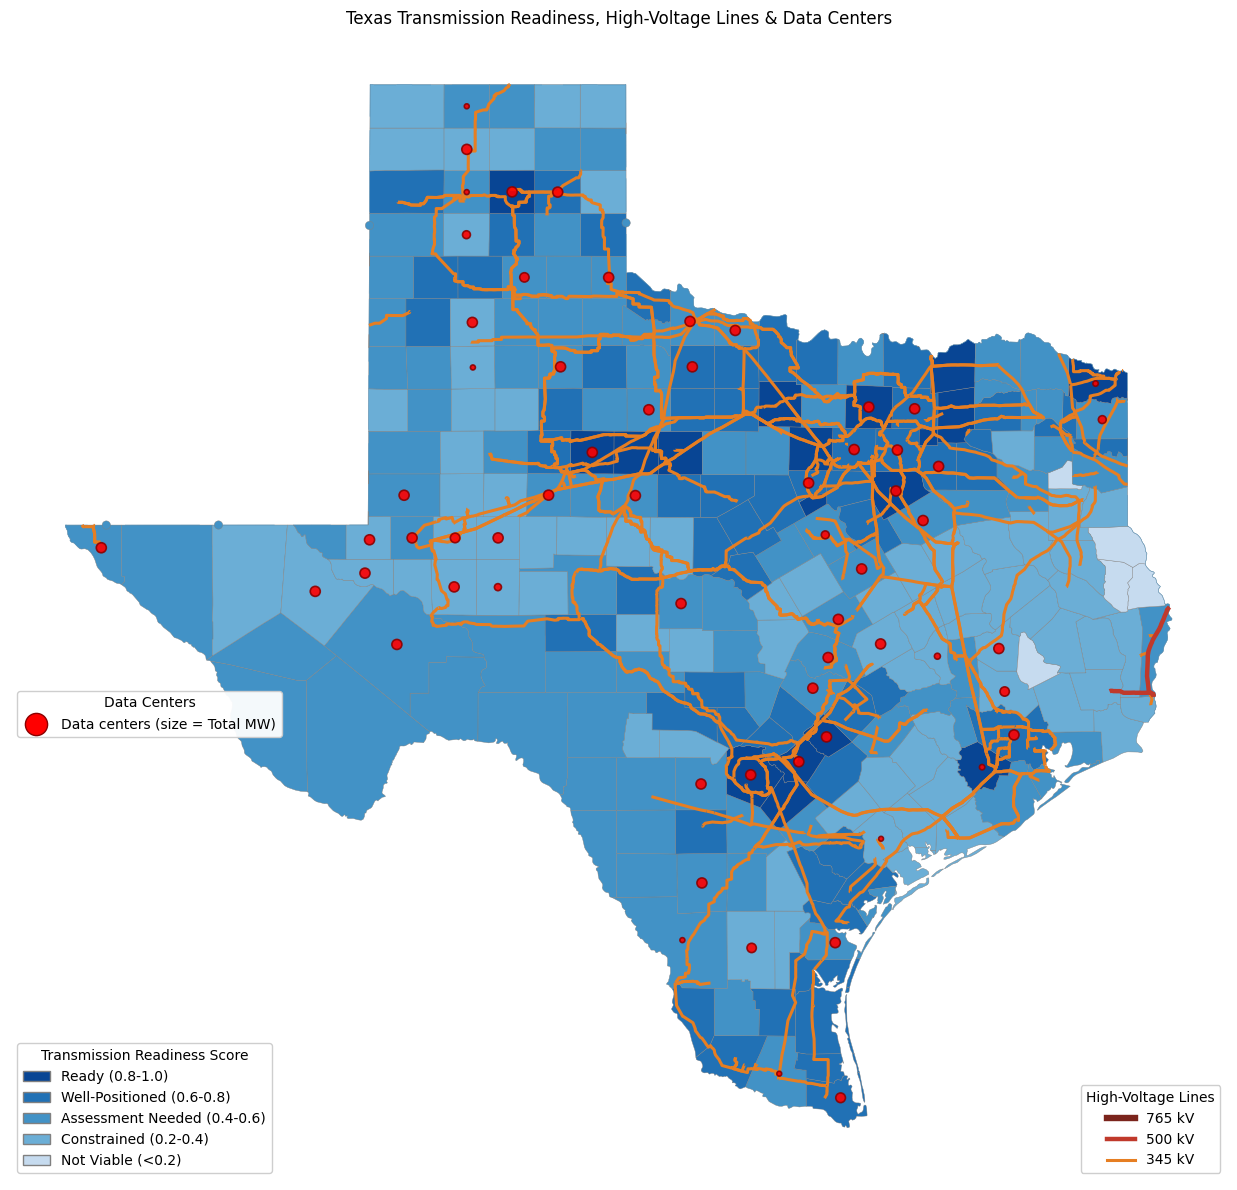

In [160]:
# Visualization: readiness choropleth + HV lines (345/500/765 kV) + data center bubbles
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from shapely.geometry import Point

# Readiness color map (exact 5 levels)
READINESS_COLORS = {
    "Transmission-Ready": "#084594",
    "Well-Positioned": "#2171b5",
    "Requires Assessment": "#4292c6",
    "Significant Constraints": "#6baed6",
    "Not Viable": "#c6dbef",
}
counties["readiness_color"] = counties["readiness_level"].map(READINESS_COLORS)

# HV lines: only 345, 500, 765 kV with colors; linewidth scales with voltage (higher = thicker)
lines_texas["VOLTAGE"] = pd.to_numeric(lines_texas["VOLTAGE"], errors="coerce")
hv_plot = lines_texas[lines_texas["VOLTAGE"].isin([345, 500, 765])].copy()
VOLTAGE_COLORS = {345: "#e67e22", 500: "#c0392b", 765: "#7b241c"}
VOLTAGE_LINEWIDTH = {345: 2.2, 500: 3.2, 765: 4.6}
hv_plot["line_color"] = hv_plot["VOLTAGE"].map(VOLTAGE_COLORS)
hv_plot["linewidth"] = hv_plot["VOLTAGE"].map(VOLTAGE_LINEWIDTH)

# Data center points: use lat/lon from sheet if present, else place at county centroid
# Use projected CRS for centroid to avoid geographic CRS warning, then get WGS84 lon/lat
TEXAS_CRS = "EPSG:3083"
counties_proj = counties.to_crs(TEXAS_CRS)
centroids_proj = counties_proj.geometry.centroid
centroids_wgs84 = gpd.GeoSeries(centroids_proj, crs=TEXAS_CRS).to_crs("EPSG:4326")
county_centroids = counties.copy()
county_centroids["lon"] = centroids_wgs84.x.values
county_centroids["lat"] = centroids_wgs84.y.values

# Build lookup: use only columns that contain actual county names (strings), not numeric IDs
name_to_geom = None
for name_col in ["NAME_2", "name", "NAME_1", "admin2", "COUNTY"]:
    if name_col not in county_centroids.columns:
        continue
    keys = county_centroids[name_col].astype(str).str.upper().str.strip().str.replace(" COUNTY", "").str.strip()
    county_centroids["_name_key"] = keys
    # Skip if keys look like numeric IDs (e.g. 89, 86) not names (e.g. HARRIS)
    if keys.str.match(r"^\d+$").all():
        continue
    g = county_centroids.drop_duplicates(subset=["_name_key"], keep="first")
    name_to_geom = g.set_index("_name_key")[["lon", "lat"]]
    break
if name_to_geom is None:
    name_to_geom = county_centroids.set_index(county_centroids.index)[["lon", "lat"]]

def normalize_county(s):
    s = str(s or "").upper().strip()
    for x in [", TX", ", TEXAS", " COUNTY", " CO."]:
        s = s.replace(x, "")
    return s.strip()

def get_county_lon_lat(cname, name_to_geom):
    if name_to_geom is None or cname is None or (isinstance(cname, float) and np.isnan(cname)):
        return None, None
    cname = normalize_county(cname)
    if not cname:
        return None, None
    # Exact match
    for key in [cname, cname + " COUNTY"]:
        if key in name_to_geom.index:
            r = name_to_geom.loc[key]
            r = r.iloc[0] if hasattr(r, "iloc") and len(r.shape) > 0 else r
            return float(r["lon"]), float(r["lat"])
    # Fallback: first key that equals cname when normalized (e.g. "HARRIS CO" -> HARRIS)
    for key in name_to_geom.index:
        if normalize_county(key) == cname or key == cname:
            r = name_to_geom.loc[key]
            r = r.iloc[0] if hasattr(r, "iloc") and len(r.shape) > 0 else r
            return float(r["lon"]), float(r["lat"])
    return None, None

dc_pts = []
dc_sizes = []
for _, row in dc_df.iterrows():
    lat, lon = row["lat"], row["lon"]
    if pd.isna(lat) or pd.isna(lon):
        county_val = row.get("County")
        lon, lat = get_county_lon_lat(county_val, name_to_geom)
        if lon is None or lat is None:
            continue
    dc_pts.append((lon, lat))
    mw = float(row["Total_MW"])
    # Keep bubbles small (no larger than county): size scales with sqrt(MW), capped
    dc_sizes.append(max(8, min(52, 10 + 3.5 * np.sqrt(max(0.1, mw)))))

# Keep only data centers inside Texas
texas_geom = texas.geometry.unary_union
dc_pts_inside = []
dc_sizes_inside = []
for (lon, lat), sz in zip(dc_pts, dc_sizes):
    pt = Point(lon, lat)
    if texas_geom.contains(pt) or texas_geom.intersects(pt):
        dc_pts_inside.append((lon, lat))
        dc_sizes_inside.append(sz)
dc_pts = dc_pts_inside
dc_sizes = dc_sizes_inside
print(f"Data centers to plot: {len(dc_pts)} (from {len(dc_df)} rows in sheet, all within Texas)")
if len(dc_pts) == 0 and len(dc_df) > 0:
    sample_counties = dc_df["County"].dropna().astype(str).head(5).tolist()
    keys = list(name_to_geom.index)[:15] if name_to_geom is not None else []
    print(f"  Excel county sample: {sample_counties}")
    print(f"  Map county keys (first 15): {keys}")

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_aspect("equal")

# 1) Choropleth: readiness
counties.plot(ax=ax, color=counties["readiness_color"], edgecolor="gray", linewidth=0.3)
# 2) HV lines by voltage (thicker = higher voltage)
for volt in [345, 500, 765]:
    subset = hv_plot[hv_plot["VOLTAGE"] == volt]
    if len(subset) > 0:
        lw = VOLTAGE_LINEWIDTH[volt]
        subset.plot(ax=ax, color=VOLTAGE_COLORS[volt], linewidth=lw)
# 3) Data center bubbles: big red dots, size = Total MW (more MW = bigger)
if dc_pts:
    lons, lats = zip(*dc_pts)
    ax.scatter(lons, lats, s=dc_sizes, c="red", edgecolors="darkred", linewidths=1.2, zorder=10, alpha=0.9)

# Legend: Data Centers (on top), then Readiness below
legend_dc = [
    Line2D([0], [0], marker="o", markersize=16, color="red", markerfacecolor="red", markeredgecolor="darkred", label="Data centers (size = Total MW)", linestyle="None"),
]
leg_dc = ax.legend(handles=legend_dc, title="Data Centers", loc="lower left", bbox_to_anchor=(0, 0.38), framealpha=0.95)
ax.add_artist(leg_dc)
legend_elements_1 = [
    Patch(facecolor="#084594", edgecolor="gray", label="Ready (0.8-1.0)"),
    Patch(facecolor="#2171b5", edgecolor="gray", label="Well-Positioned (0.6-0.8)"),
    Patch(facecolor="#4292c6", edgecolor="gray", label="Assessment Needed (0.4-0.6)"),
    Patch(facecolor="#6baed6", edgecolor="gray", label="Constrained (0.2-0.4)"),
    Patch(facecolor="#c6dbef", edgecolor="gray", label="Not Viable (<0.2)"),
]
leg1 = ax.legend(handles=legend_elements_1, title="Transmission Readiness Score", loc="lower left", framealpha=0.95)
ax.add_artist(leg1)
# Legend: Section 2 - HV lines (line thickness reflects voltage)
legend_elements_2 = [
    Line2D([0], [0], color=VOLTAGE_COLORS[765], linewidth=VOLTAGE_LINEWIDTH[765], label="765 kV"),
    Line2D([0], [0], color=VOLTAGE_COLORS[500], linewidth=VOLTAGE_LINEWIDTH[500], label="500 kV"),
    Line2D([0], [0], color=VOLTAGE_COLORS[345], linewidth=VOLTAGE_LINEWIDTH[345], label="345 kV"),
]
ax.legend(handles=legend_elements_2, title="High-Voltage Lines", loc="lower right", framealpha=0.95)
ax.set_title("Texas Transmission Readiness, High-Voltage Lines & Data Centers")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [161]:
# % of data-centre MW in counties where transmission readiness_score < 0.5
def get_county_key(cname, name_to_geom):
    """Return county key (for merging with readiness) or None."""
    if name_to_geom is None or cname is None or (isinstance(cname, float) and np.isnan(cname)):
        return None
    cname = normalize_county(cname)
    if not cname:
        return None
    # Exact: full string and with " COUNTY"
    for key in [cname, cname + " COUNTY"]:
        if key in name_to_geom.index:
            return key
    # If "City, County" format, try each part (e.g. "AUSTIN, TRAVIS" -> try "TRAVIS", "AUSTIN")
    for part in cname.split(","):
        part = part.strip()
        if not part:
            continue
        for key in [part, part + " COUNTY"]:
            if key in name_to_geom.index:
                return key
    # Fallback: key that normalizes to cname or equals cname
    for key in name_to_geom.index:
        if normalize_county(key) == cname or key == cname:
            return key
    return None

# Map county key -> readiness_score (build from counties using same name column as map cell)
name_col = next((c for c in ["NAME_2", "name", "NAME_1", "admin2", "COUNTY"] if c in counties.columns), None)
if name_col is not None:
    keys = counties[name_col].astype(str).str.upper().str.strip().str.replace(" COUNTY", "").str.strip()
    key_to_readiness = counties.assign(_key=keys).drop_duplicates(subset=["_key"]).set_index("_key")["readiness_score"]
else:
    key_to_readiness = pd.Series(dtype=float)
dc_df = dc_df.copy()
dc_df["_county_key"] = dc_df["County"].apply(lambda x: get_county_key(x, name_to_geom))
dc_df["readiness_score"] = dc_df["_county_key"].map(key_to_readiness)

# Fallback: for rows with lat/lon but no name match, assign county by point-in-polygon
unmatched = dc_df["_county_key"].isna() & dc_df["lon"].notna() & dc_df["lat"].notna()
if unmatched.any() and name_col is not None:
    from shapely.geometry import Point
    pts = gpd.GeoDataFrame(
        geometry=[Point(float(row["lon"]), float(row["lat"])) for _, row in dc_df.loc[unmatched].iterrows()],
        crs="EPSG:4326",
    )
    counties_wgs84 = counties.to_crs("EPSG:4326")
    joined = gpd.sjoin(pts, counties_wgs84[[name_col, "geometry"]], predicate="within", how="left")
    keys = joined[name_col].astype(str).str.upper().str.strip().str.replace(" COUNTY", "").str.strip()
    for idx, (orig_idx, key) in enumerate(zip(dc_df.loc[unmatched].index, keys)):
        if key in key_to_readiness.index:
            dc_df.loc[orig_idx, "_county_key"] = key
            dc_df.loc[orig_idx, "readiness_score"] = key_to_readiness[key]

total_dc_mw = dc_df["Total_MW"].sum()
mask_below = dc_df["readiness_score"] < 0.5
# Exclude rows that didn't match a county (readiness_score is NaN)
mw_below_50 = dc_df.loc[mask_below & dc_df["readiness_score"].notna(), "Total_MW"].sum()
mw_matched = dc_df["readiness_score"].notna()
total_matched_mw = dc_df.loc[mw_matched, "Total_MW"].sum()
pct_mw_below_50 = 100 * mw_below_50 / total_dc_mw if total_dc_mw else 0

summary = pd.DataFrame({
    "Metric": [
        "Total data-centre MW",
        "DC MW in counties with readiness_score < 0.5",
        "% of data-centre MW in counties with readiness_score < 0.5",
    ],
    "Value": [
        f"{total_dc_mw:,.1f} MW",
        f"{mw_below_50:,.1f} MW",
        f"{pct_mw_below_50:.1f}%",
    ],
})
print("Share of data-centre MW in counties where transmission readiness score is below 0.5:")
display(summary)
if not mw_matched.all():
    unmapped_mw = dc_df.loc[~mw_matched, "Total_MW"].sum()
    print(f"Note: {unmapped_mw:,.1f} MW could not be matched to a county and are excluded from the percentage.")

Share of data-centre MW in counties where transmission readiness score is below 0.5:


,Metric,Value
0,Total data-centre MW,"41,444.8 MW"
1,DC MW in counties with readiness_score < 0.5,0.0 MW
2,% of data-centre MW in counties with readiness...,0.0%


Note: 41,444.8 MW could not be matched to a county and are excluded from the percentage.


In [162]:
counties

,FEATURECLA,SCALERANK,ADM2_CODE,ISO_3166_2,ISO_A2,ADM0_SR,NAME,NAME_ALT,NAME_LOCAL,TYPE,...,capacity_density,hv_line_count,distance_to_metro,area_sq_miles,capacity_pct,hv_pct,proximity_pct,readiness_score,readiness_level,readiness_color
89,Admin-2 scale rank,0,USA-48043,US-48,US,1,Brewster,Brewster County,None,County,...,0.001898,0,500.0,6138.001519,0.679443,0.168990,0.501742,0.490767,Requires Assessment,#4292c6
86,Admin-2 scale rank,0,USA-48377,US-48,US,1,Presidio,Presidio County,None,County,...,-0.241549,0,500.0,3812.309117,0.519164,0.168990,0.501742,0.410627,Requires Assessment,#4292c6
88,Admin-2 scale rank,0,USA-48443,US-48,US,1,Terrell,Terrell County,None,County,...,0.000405,0,500.0,2325.565989,0.668990,0.168990,0.501742,0.485540,Requires Assessment,#4292c6
2984,Admin-2 scale rank,0,USA-48105,US-48,US,1,Crockett,Crockett County,None,County,...,-3.146897,2,500.0,2780.851322,0.435540,0.498258,0.501742,0.467596,Requires Assessment,#4292c6
2931,Admin-2 scale rank,0,USA-48371,US-48,US,1,Pecos,Pecos County,None,County,...,-5.155664,3,500.0,4845.230160,0.383275,0.604530,0.501742,0.473345,Requires Assessment,#4292c6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,Admin-2 scale rank,0,USA-48295,US-48,US,1,Lipscomb,Lipscomb County,None,County,...,-33.198007,0,500.0,930.684669,0.177700,0.168990,0.501742,0.239895,Significant Constraints,#6baed6
609,Admin-2 scale rank,0,USA-48357,US-48,US,1,Ochiltree,Ochiltree County,None,County,...,-19.144488,0,500.0,919.309967,0.250871,0.168990,0.501742,0.276481,Significant Constraints,#6baed6
608,Admin-2 scale rank,0,USA-40007,US-40,US,1,Beaver,Beaver County,None,County,...,0.000000,0,500.0,0.000000,0.608014,0.168990,0.501742,0.455052,Requires Assessment,#4292c6
610,Admin-2 scale rank,0,USA-40139,US-40,US,1,Texas,Texas County,None,County,...,0.000000,0,500.0,0.000000,0.608014,0.168990,0.501742,0.455052,Requires Assessment,#4292c6
